In [4]:
# import libraries
from cil.optimisation.functions import L2NormSquared, MixedL21Norm
from cil.optimisation.operators import GradientOperator
from cil.optimisation.algorithms import PDHG
from cil.utilities.dataexample import TestData
from cil.utilities.display import plotter2D

import matplotlib.pyplot as plt
import numpy as np

import os, sys

In [5]:
# Load an image from the CIL gallery. 
loader = TestData(data_dir=os.path.join(sys.prefix, 'share','cil'))
data = loader.load(TestData.SHAPES)
ig = data.geometry

In [6]:
# Add gaussian noise
noisy_data= TestData.random_noise(data, mode = 'gaussian', seed = 10, var = 0.005)

In [9]:
# Regularisation parameter fo the Total variation term
alpha = 0.1

F = alpha * MixedL21Norm()
G = 0.5 * L2NormSquared(b=noisy_data)
K = GradientOperator(ig)

# Compute operator Norm
normK = K.norm()

# Primal & dual stepsizes
sigma = 1.
tau = 1/(sigma*normK**2)

# Setup and run the PDHG algorithm
pdhg = PDHG(f=F, g=G, operator=K, tau=tau, sigma=sigma,
            max_iteration = 500, update_objective_interval = 100)
pdhg.run(verbose=2)

Initialised GradientOperator with C backend running with  20  threads
PDHG setting up
PDHG configured
     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        500         0.006    1.03383e+04  -0.00000e+00    1.03383e+04
      100        500         0.003    2.30330e+02   2.30111e+02    2.19142e-01
      200        500         0.003    2.30219e+02   2.30146e+02    7.28333e-02
      300        500         0.003    2.30190e+02   2.30153e+02    3.72131e-02
      400        500         0.003    2.30177e+02   2.30155e+02    2.22366e-02
      500        500         0.003    2.30171e+02   2.30156e+02    1.48712e-02
----------------------------------------------------------------------------
      500        500         0.003    2.30171e+02   2.30156e+02    1.48712e-02
Stop criterion has been reached.



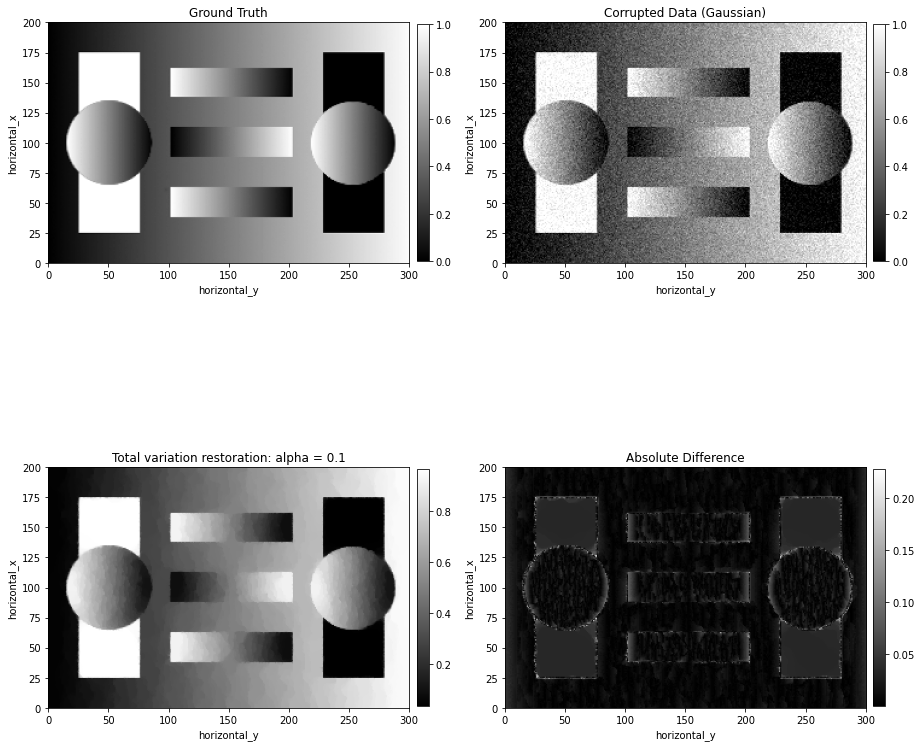

In [11]:
plotter2D([data, noisy_data, pdhg.solution, (pdhg.solution-data).abs()],
          titles=["Ground Truth", 
                  "Corrupted Data (Gaussian)", 
                  "Total variation restoration: alpha = {}".format(alpha),
                  "Absolute Difference"])